In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_parquet('GlobalGeoTree-6M/GlobalGeoTreeNoMissing.parquet')
df = df.sample(500000)

In [2]:
# Create a reproducible train/test split and save to disk (parquet)
# Using pandas.sample to avoid adding scikit-learn dependency.
# Set test_frac to your desired test set proportion.

test_frac = 0.2

# For large DataFrames this will still operate in memory; if memory is constrained,
# consider streaming or writing indices and filtering on disk.
train_df = df.sample(frac=1 - test_frac, random_state=42)
test_df = df.drop(train_df.index)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# File paths to save
train_path = 'GlobalGeoTree-6M/train.parquet'
test_path = 'GlobalGeoTree-6M/test.parquet'

# Save (use pyarrow engine if available for speed)
train_df.to_parquet(train_path, index=False)
test_df.to_parquet(test_path, index=False)

print(f"Saved train to {train_path}, test to {test_path}")

Train shape: (400000, 32)
Test shape: (100000, 32)
Saved train to GlobalGeoTree-6M/train.parquet, test to GlobalGeoTree-6M/test.parquet
Saved train to GlobalGeoTree-6M/train.parquet, test to GlobalGeoTree-6M/test.parquet


In [8]:
#device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#hyperparameters
hidden_size = 20
num_classes = 2725
num_epochs = 3
batch_size = 64
learning_rate=0.0005

#dataset
import numpy as np
from torch.utils.data import TensorDataset

# Prepare feature list and target (assume every feature is numeric except the target)
features = list(df)
undesirables = ['sample_id','level0','level1_family','level2_genus','level3_species']
target = 'level1_family'
features = [e for e in features if e not in undesirables and e != target]

# Set input_size AFTER features are finalized
input_size = len(features)
print(f"Input size (number of features): {input_size}")

from sklearn.model_selection import train_test_split

# Remove classes with only one sample (TabNet and stratify require at least 2 samples per class)
class_counts = df[target].value_counts()
singleton_classes = class_counts[class_counts == 1].index.tolist()
num_singletons = len(singleton_classes)
if num_singletons > 0:
    print(f"Removing {num_singletons} classes with only one sample (singletons). These rows will be dropped.")
    # Drop rows belonging to singleton classes
    df = df[~df[target].isin(singleton_classes)].reset_index(drop=True)
else:
    print("No singleton classes found.")

# After removing singletons, recompute class counts for splitting
class_counts = df[target].value_counts()

# Robust train/test splitting: stratify when possible
if class_counts.min() < 2:
    # this condition should rarely trigger since we removed singletons, but keep a fallback
    print(f"Warning: some classes still have fewer than 2 samples (min={class_counts.min()}). Using non-stratified split.")
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    X_train = train_df[features]
    y_train = train_df[target]
    X_test = test_df[features]
    y_test = test_df[target]
else:
    X_train, X_test, y_train, y_test = train_test_split(
        df[features], df[target],
        test_size=0.2,
        stratify=df[target],  # <<< important
        random_state=42,
    )
    # keep train_df/test_df available for downstream code
    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)

# Numeric preprocessing: compute train means/stds, fillna and scale
if features:
    num_means = X_train.mean()
    num_stds = X_train.std().replace(0,1)
else:
    num_means = pd.Series(dtype=float)
    num_stds = pd.Series(dtype=float)

def preprocess_numeric(df_in):
    if not features:
        return np.zeros((len(df_in),0), dtype=np.float32)
    X = df_in[features].fillna(num_means).astype(np.float32)
    X = ((X - num_means) / num_stds).to_numpy(dtype=np.float32)
    return X

# Encode target using train categories to guarantee consistent mapping
train_target_cat = pd.Categorical(y_train)
target_categories = list(train_target_cat.categories)
target_map = {v:i for i,v in enumerate(target_categories)}
print(f"Target classes (train): {len(target_categories)}")

def encode_target(series):
    return series.map(target_map).fillna(-1).astype(np.int64).to_numpy()

# Build arrays for train and test
X_train = preprocess_numeric(train_df)
y_train = encode_target(y_train)
X_test = preprocess_numeric(test_df)
y_test = encode_target(y_test)

# Convert to torch tensors (may be large for full dataset)
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test)

# Create TensorDatasets and DataLoaders (same format as before)
train_tensor = TensorDataset(X_train_t, y_train_t)
test_tensor = TensorDataset(X_test_t, y_test_t)

train_loader = torch.utils.data.DataLoader(dataset=train_tensor, batch_size = batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_tensor, batch_size = batch_size, shuffle=False)


Input size (number of features): 27
No singleton classes found.
Target classes (train): 241
Target classes (train): 241


In [4]:
examples = iter(train_loader)
samples, labels = next(examples)
print(samples.shape, labels.shape)

torch.Size([64, 27]) torch.Size([64])


epoch 1/3, step 64/6250, loss=5.3594
epoch 1/3, step 128/6250, loss=5.0600
epoch 1/3, step 192/6250, loss=4.5155
epoch 1/3, step 256/6250, loss=4.1686
epoch 1/3, step 320/6250, loss=3.9080
epoch 1/3, step 384/6250, loss=4.1041
epoch 1/3, step 448/6250, loss=3.9044
epoch 1/3, step 512/6250, loss=3.8826
epoch 1/3, step 320/6250, loss=3.9080
epoch 1/3, step 384/6250, loss=4.1041
epoch 1/3, step 448/6250, loss=3.9044
epoch 1/3, step 512/6250, loss=3.8826
epoch 1/3, step 576/6250, loss=3.5665
epoch 1/3, step 640/6250, loss=3.6699
epoch 1/3, step 704/6250, loss=3.5723
epoch 1/3, step 768/6250, loss=3.6447
epoch 1/3, step 576/6250, loss=3.5665
epoch 1/3, step 640/6250, loss=3.6699
epoch 1/3, step 704/6250, loss=3.5723
epoch 1/3, step 768/6250, loss=3.6447
epoch 1/3, step 832/6250, loss=3.3723
epoch 1/3, step 896/6250, loss=3.6905
epoch 1/3, step 960/6250, loss=3.5529
epoch 1/3, step 1024/6250, loss=3.2822
epoch 1/3, step 832/6250, loss=3.3723
epoch 1/3, step 896/6250, loss=3.6905
epoch 1/3, s

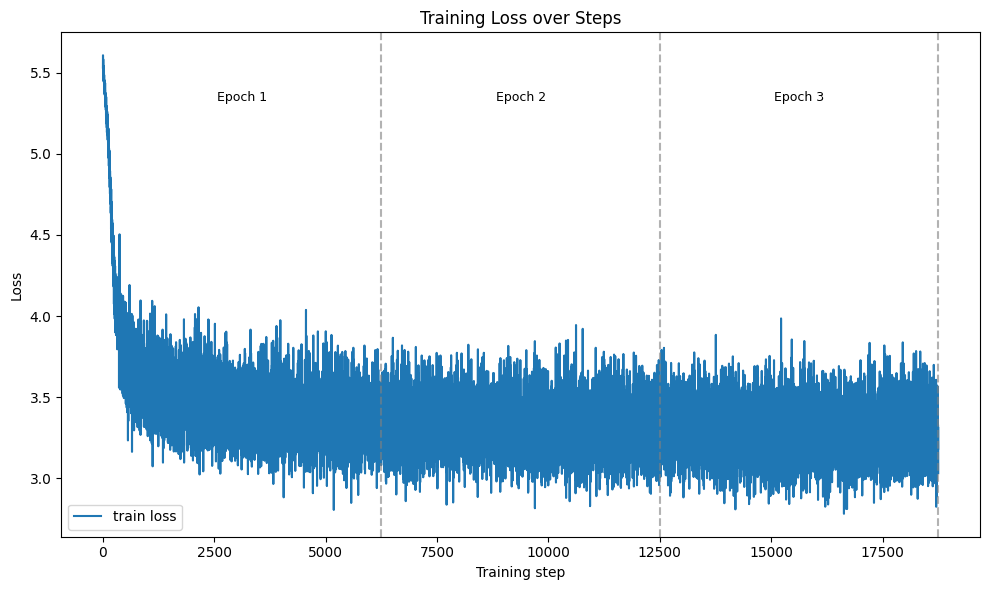

In [10]:
class NeuralNet(nn.Module):
    def __init__(self,input_size, hidden_size,num_classes):
        super(NeuralNet, self).__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out

# ensure input_size matches prepared data
if 'X_train_t' in globals():
    input_size = X_train_t.shape[1]
else:
    # fallback to previously set value
    pass

model = NeuralNet(input_size, hidden_size, len(target_categories))
model.to(device)

# loss and optimiser (instantiate loss)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# track loss over steps and epoch boundaries
loss_history = []
epoch_boundary_steps = []
global_step = 0

# training loop
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    model.train()
    for i, (data,labels) in enumerate(train_loader):
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # forward
        outputs = model(data)
        loss = criterion(outputs, labels)

        # backwards
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # record loss and step
        loss_history.append(loss.item())
        global_step += 1

        if (i+1) % 64 == 0:
            print(f'epoch {epoch+1}/{num_epochs}, step {i+1}/{n_total_steps}, loss={loss.item():.4f}')

    # mark epoch boundary after finishing epoch
    epoch_boundary_steps.append(global_step)

# test
model.eval()
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    for data, labels in test_loader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)
        outputs = model(data)

        # value, index
        _, predictions = torch.max(outputs,1)
        n_samples += labels.shape[0]
        n_correct += (predictions == labels).sum().item()

acc = 100 * n_correct / n_samples if n_samples > 0 else 0
print(f'accuracy = {acc:.2f}%')

# Plot loss over training steps with epoch markers
import matplotlib.pyplot as plt
if len(loss_history) > 0:
    plt.figure(figsize=(10,6))
    plt.plot(loss_history, label='train loss')
    # draw vertical lines for epoch boundaries
    for eb in epoch_boundary_steps:
        plt.axvline(eb, color='gray', linestyle='--', alpha=0.6)
    # annotate epoch numbers between boundaries
    start = 0
    for idx, eb in enumerate(epoch_boundary_steps):
        mid = (start + eb) / 2 if eb > start else start
        y_pos = max(loss_history) if len(loss_history)>0 else 0
        plt.text(mid, y_pos*0.95, f'Epoch {idx+1}', ha='center', fontsize=9, color='black')
        start = eb
    plt.xlabel('Training step')
    plt.ylabel('Loss')
    plt.title('Training Loss over Steps')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No loss history recorded; training loop may not have run.')

In [6]:

# ============================================================================
# HIERARCHICAL LOSS FUNCTIONS for Tree Classification
# ============================================================================
# Your data has a hierarchy: level0 -> level1_family -> level2_genus -> level3_species
# These loss functions penalize mistakes less if the prediction is wrong but in the same parent category.

import torch
import torch.nn as nn
import torch.nn.functional as F

# First, build a hierarchy mapping: level1_family_idx -> level0_idx
# This allows us to check if two families are in the same level0 category

def build_hierarchy_map(df, target_col='level1_family', parent_col='level0', target_categories=None):
    """
    Build a mapping from target class index to parent class index.
    
    Args:
        df: DataFrame with 'target_col' and 'parent_col'
        target_col: target column (e.g., 'level1_family')
        parent_col: parent column (e.g., 'level0')
        target_categories: list of target classes in the order they were encoded
        
    Returns:
        hierarchy_dict: {target_idx: parent_idx, ...}
        parent_to_indices: {parent_idx: [target_indices], ...}
    """
    if target_categories is None:
        target_categories = list(df[target_col].unique())
    
    # Create mapping for parent categories
    parent_categories = list(df[parent_col].unique())
    parent_map = {v: i for i, v in enumerate(parent_categories)}
    
    # For each target class, find its parent
    hierarchy_dict = {}
    parent_to_indices = {i: [] for i in range(len(parent_categories))}
    
    for target_idx, target_name in enumerate(target_categories):
        # Find a sample with this target class
        sample_rows = df[df[target_col] == target_name]
        if len(sample_rows) > 0:
            parent_name = sample_rows[parent_col].iloc[0]
            parent_idx = parent_map[parent_name]
            hierarchy_dict[target_idx] = parent_idx
            parent_to_indices[parent_idx].append(target_idx)
    
    return hierarchy_dict, parent_to_indices, parent_categories

# Build the hierarchy now (using the full df and target_categories from preprocessing)
print("Building hierarchy mapping from level1_family -> level0...")
hierarchy_dict, parent_to_indices, parent_categories = build_hierarchy_map(
    df, 
    target_col='level1_family', 
    parent_col='level0',
    target_categories=target_categories
)
print(f"  Hierarchy map size: {len(hierarchy_dict)}")
print(f"  Parent categories: {len(parent_categories)} (e.g., {parent_categories[:3]}...)")
print(f"  Parent to child mapping (sample): {dict(list(parent_to_indices.items())[:2])}")


class HierarchicalCrossEntropyLoss(nn.Module):
    """
    Hierarchical Cross Entropy Loss.
    
    Penalizes exact-class mismatches fully, but reduces penalty if the prediction
    is in the same parent category (e.g., same level0) as the ground truth.
    
    Loss = -log(softmax(logits)) for exact class match
    Loss = alpha * -log(softmax(logits)) for same-parent, wrong-class match
    Loss = 1.0 * -log(softmax(logits)) for different-parent match
    
    Args:
        hierarchy_dict: {target_idx: parent_idx, ...}
        alpha: penalty reduction for same-parent mismatches (default 0.5)
        device: torch device
    """
    def __init__(self, hierarchy_dict, alpha=0.5, device='cpu'):
        super(HierarchicalCrossEntropyLoss, self).__init__()
        self.hierarchy_dict = hierarchy_dict
        self.alpha = alpha
        self.device = device
        
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) raw model outputs
            targets: (batch_size,) ground truth class indices
            
        Returns:
            loss: scalar loss value
        """
        batch_size = logits.shape[0]
        num_classes = logits.shape[1]
        
        # Compute standard cross-entropy (unreduced, per-sample)
        log_probs = F.log_softmax(logits, dim=1)  # (batch_size, num_classes)
        base_loss = F.nll_loss(log_probs, targets, reduction='none')  # (batch_size,)
        
        # Compute hierarchical penalty: check if predicted class and target share parent
        losses = []
        for i in range(batch_size):
            target_idx = targets[i].item()
            target_parent = self.hierarchy_dict.get(target_idx, -1)
            
            # Find predicted class
            pred_idx = torch.argmax(logits[i]).item()
            pred_parent = self.hierarchy_dict.get(pred_idx, -1)
            
            # Apply penalty reduction if same parent and different class
            if target_parent != -1 and pred_parent != -1:
                if target_parent == pred_parent and target_idx != pred_idx:
                    # Same parent, wrong class: reduce penalty
                    losses.append(base_loss[i] * self.alpha)
                else:
                    # Different parent or exact match: use full penalty
                    losses.append(base_loss[i])
            else:
                # Missing hierarchy info: use full penalty
                losses.append(base_loss[i])
        
        return torch.mean(torch.stack(losses))


class HierarchicalLabelSmoothing(nn.Module):
    """
    Hierarchical Label Smoothing Loss.
    
    Instead of one-hot encoding, smooth the target distribution to assign
    lower probability mass to siblings in the same parent category.
    
    Args:
        hierarchy_dict: {target_idx: parent_idx, ...}
        parent_to_indices: {parent_idx: [target_indices], ...}
        smooth_factor: mass to distribute among sibling classes (default 0.1)
        device: torch device
    """
    def __init__(self, hierarchy_dict, parent_to_indices, smooth_factor=0.1, device='cpu'):
        super(HierarchicalLabelSmoothing, self).__init__()
        self.hierarchy_dict = hierarchy_dict
        self.parent_to_indices = parent_to_indices
        self.smooth_factor = smooth_factor
        self.device = device
        
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) raw model outputs
            targets: (batch_size,) ground truth class indices
            
        Returns:
            loss: scalar loss value
        """
        batch_size = logits.shape[0]
        num_classes = logits.shape[1]
        
        # Create smooth target distributions
        smooth_targets = torch.zeros_like(logits)  # (batch_size, num_classes)
        
        for i in range(batch_size):
            target_idx = targets[i].item()
            target_parent = self.hierarchy_dict.get(target_idx, -1)
            
            # Assign high probability to the true class
            smooth_targets[i, target_idx] = 1.0 - self.smooth_factor
            
            # Distribute smooth_factor among siblings (other classes with same parent)
            if target_parent != -1 and target_parent in self.parent_to_indices:
                siblings = self.parent_to_indices[target_parent]
                num_siblings = len(siblings)
                if num_siblings > 1:
                    sibling_mass = self.smooth_factor / (num_siblings - 1)  # exclude self
                    for sibling_idx in siblings:
                        if sibling_idx != target_idx:
                            smooth_targets[i, sibling_idx] = sibling_mass
        
        # Compute KL divergence (or cross-entropy with soft targets)
        log_probs = F.log_softmax(logits, dim=1)
        loss = -(smooth_targets * log_probs).sum(dim=1).mean()
        
        return loss


# Example: Instantiate both loss functions (you can use one or the other)
print("\n" + "="*70)
print("Hierarchical Loss Functions Ready:")
print("  1. HierarchicalCrossEntropyLoss: Reduces penalty for same-parent mismatches")
print("  2. HierarchicalLabelSmoothing: Smooths target distribution across siblings")
print("="*70)


Building hierarchy mapping from level1_family -> level0...
  Hierarchy map size: 241
  Parent categories: 4 (e.g., ['Deciduous Broadleaf', 'Evergreen Broadleaf', 'Evergreen Needleleaf']...)
  Parent to child mapping (sample): {0: [3, 6, 7, 8, 10, 26, 27, 28, 33, 35, 38, 39, 41, 42, 43, 48, 49, 52, 53, 54, 59, 61, 63, 64, 65, 66, 79, 83, 84, 86, 92, 94, 96, 98, 103, 105, 106, 107, 108, 109, 112, 114, 115, 117, 121, 122, 123, 130, 135, 136, 137, 141, 145, 147, 154, 158, 159, 170, 178, 179, 182, 190, 193, 195, 198, 208, 210, 211, 212, 220, 222, 225, 229, 233], 1: [0, 1, 2, 4, 5, 9, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 29, 30, 31, 32, 34, 36, 37, 40, 44, 45, 46, 50, 55, 56, 57, 58, 60, 62, 67, 68, 69, 70, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 87, 88, 89, 90, 91, 93, 95, 97, 99, 100, 101, 102, 104, 110, 111, 113, 116, 118, 119, 120, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 138, 139, 140, 142, 143, 144, 146, 148, 149, 150, 151, 152, 153, 155, 156, 157, 160, 161,


EXAMPLE: Training with Hierarchical Loss
epoch 1/3, step 64/6250, hier_loss=3.9970
epoch 1/3, step 64/6250, hier_loss=3.9970
epoch 1/3, step 128/6250, hier_loss=3.7503
epoch 1/3, step 128/6250, hier_loss=3.7503
epoch 1/3, step 192/6250, hier_loss=3.5547
epoch 1/3, step 192/6250, hier_loss=3.5547
epoch 1/3, step 256/6250, hier_loss=3.1374
epoch 1/3, step 256/6250, hier_loss=3.1374
epoch 1/3, step 320/6250, hier_loss=3.0797
epoch 1/3, step 320/6250, hier_loss=3.0797
epoch 1/3, step 384/6250, hier_loss=3.0352
epoch 1/3, step 384/6250, hier_loss=3.0352
epoch 1/3, step 448/6250, hier_loss=3.1168
epoch 1/3, step 448/6250, hier_loss=3.1168
epoch 1/3, step 512/6250, hier_loss=2.7761
epoch 1/3, step 512/6250, hier_loss=2.7761
epoch 1/3, step 576/6250, hier_loss=2.9258
epoch 1/3, step 576/6250, hier_loss=2.9258
epoch 1/3, step 640/6250, hier_loss=3.0105
epoch 1/3, step 640/6250, hier_loss=3.0105
epoch 1/3, step 704/6250, hier_loss=3.0100
epoch 1/3, step 704/6250, hier_loss=3.0100
epoch 1/3, ste

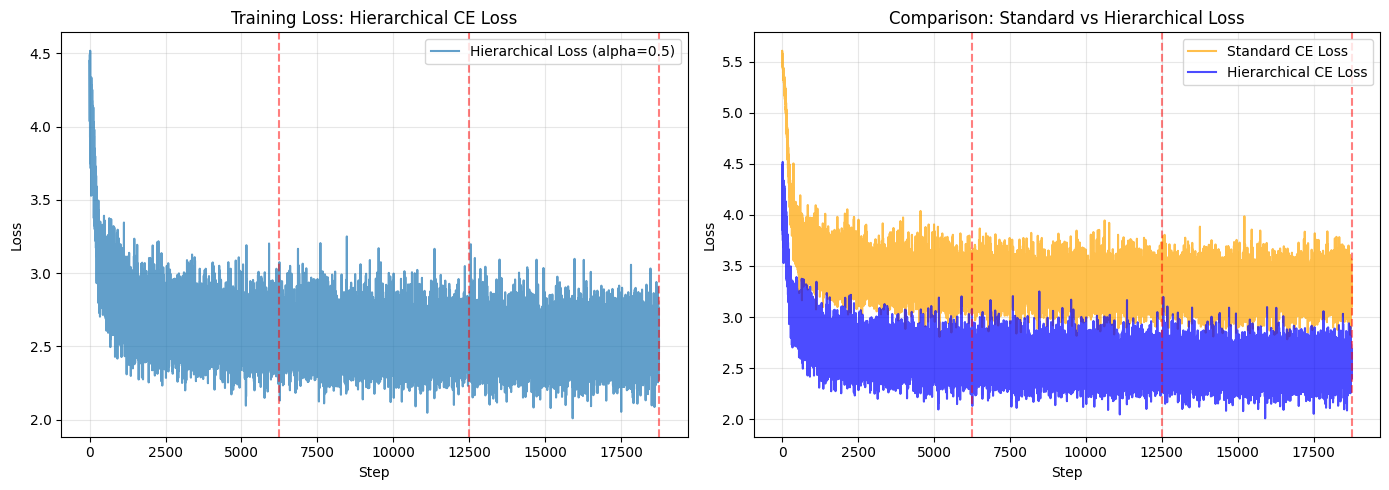

Hierarchical Loss Training Complete!


In [11]:

# ============================================================================
# EXAMPLE: Using Hierarchical Loss with Your Model
# ============================================================================
# This cell shows how to swap out CrossEntropyLoss for HierarchicalCrossEntropyLoss
# Uncomment and run this instead of the standard training cell to use hierarchical loss.

class NeuralNet_HierarchicalDemo(nn.Module):
    """Simple 1-layer network for demo."""
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet_HierarchicalDemo, self).__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out


# Example: Train with Hierarchical Loss
# Uncomment the code below to use HierarchicalCrossEntropyLoss instead of standard CrossEntropyLoss

print("\n" + "="*70)
print("EXAMPLE: Training with Hierarchical Loss")
print("="*70)

# Create model
model_hier = NeuralNet_HierarchicalDemo(input_size, hidden_size, len(target_categories))
model_hier.to(device)

# Create hierarchical loss (alpha controls penalty reduction for same-parent mistakes)
criterion_hier = HierarchicalCrossEntropyLoss(
    hierarchy_dict=hierarchy_dict,
    alpha=0.5,  # <-- Adjust this: 0.5 means 50% penalty for same-parent, wrong-class mistakes
    device=device
)

# Standard optimizer
optimizer_hier = torch.optim.Adam(model_hier.parameters(), lr=learning_rate)

# Training loop (similar to standard, but using hierarchical loss)
loss_history_hier = []
epoch_boundary_steps_hier = []
global_step_hier = 0

n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    model_hier.train()
    for i, (data, labels) in enumerate(train_loader):
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # Forward pass
        outputs = model_hier(data)
        loss = criterion_hier(outputs, labels)  # <-- Uses hierarchical loss

        # Backward pass
        optimizer_hier.zero_grad()
        loss.backward()
        optimizer_hier.step()

        # Record loss
        loss_history_hier.append(loss.item())
        global_step_hier += 1

        if (i+1) % 64 == 0:
            print(f'epoch {epoch+1}/{num_epochs}, step {i+1}/{n_total_steps}, hier_loss={loss.item():.4f}')

    epoch_boundary_steps_hier.append(global_step_hier)

# Evaluate
model_hier.eval()
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    for data, labels in test_loader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)
        outputs = model_hier(data)

        _, predictions = torch.max(outputs, 1)
        n_samples += labels.shape[0]
        n_correct += (predictions == labels).sum().item()

accuracy_hier = 100.0 * n_correct / n_samples
print(f'\nAccuracy with Hierarchical Loss: {accuracy_hier:.2f}%')

# Plot comparison (if you also have loss_history from standard training)
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot hierarchical loss
ax1.plot(loss_history_hier, alpha=0.7, label='Hierarchical Loss (alpha=0.5)')
for boundary in epoch_boundary_steps_hier:
    ax1.axvline(x=boundary, color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss: Hierarchical CE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Optional: compare with standard loss if available
if 'loss_history' in locals():
    ax2.plot(loss_history, alpha=0.7, label='Standard CE Loss', color='orange')
    ax2.plot(loss_history_hier, alpha=0.7, label='Hierarchical CE Loss', color='blue')
    for boundary in epoch_boundary_steps:
        ax2.axvline(x=boundary, color='red', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Loss')
    ax2.set_title('Comparison: Standard vs Hierarchical Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Hierarchical Loss Training Complete!")


epoch 1/3, step 64/69896, loss=4.3901
epoch 1/3, step 128/69896, loss=3.7643
epoch 1/3, step 192/69896, loss=3.5293
epoch 1/3, step 256/69896, loss=3.4748
epoch 1/3, step 320/69896, loss=3.6983
epoch 1/3, step 384/69896, loss=3.7049
epoch 1/3, step 448/69896, loss=3.5599
epoch 1/3, step 512/69896, loss=3.2577
epoch 1/3, step 576/69896, loss=3.2642
epoch 1/3, step 640/69896, loss=3.4236
epoch 1/3, step 704/69896, loss=3.5064
epoch 1/3, step 768/69896, loss=3.1850
epoch 1/3, step 832/69896, loss=3.4260
epoch 1/3, step 896/69896, loss=3.3273
epoch 1/3, step 960/69896, loss=3.2632
epoch 1/3, step 1024/69896, loss=3.2143
epoch 1/3, step 1088/69896, loss=3.2217
epoch 1/3, step 1152/69896, loss=3.4778
epoch 1/3, step 1216/69896, loss=3.7870
epoch 1/3, step 1280/69896, loss=3.3976
epoch 1/3, step 1344/69896, loss=3.2659
epoch 1/3, step 1408/69896, loss=3.1581
epoch 1/3, step 1472/69896, loss=3.4032
epoch 1/3, step 1536/69896, loss=3.6423
epoch 1/3, step 1600/69896, loss=3.4642
epoch 1/3, step 

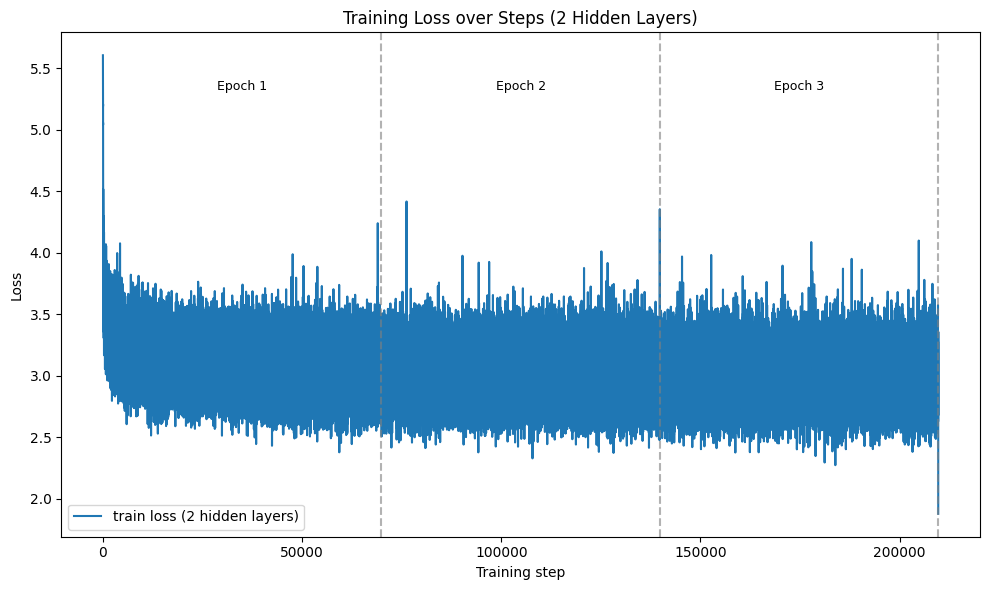

In [6]:
class NeuralNet2Layers(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
        super(NeuralNet2Layers, self).__init__()
        self.l1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.l2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.l3 = nn.Linear(hidden_size2, num_classes)

    def forward(self, x):
        out = self.l1(x)
        out = self.relu1(out)
        out = self.l2(out)
        out = self.relu2(out)
        out = self.l3(out)
        return out

# ensure input_size matches prepared data
if 'X_train_t' in globals():
    input_size = X_train_t.shape[1]
else:
    # fallback to previously set value
    pass

# Set hidden sizes for two layers
hidden_size1 = 128
hidden_size2 = 64

model2 = NeuralNet2Layers(input_size, hidden_size1, hidden_size2, len(target_categories))
model2.to(device)

# loss and optimiser (instantiate loss)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=learning_rate)

# track loss over steps and epoch boundaries
loss_history2 = []
epoch_boundary_steps2 = []
global_step = 0

# training loop
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    model2.train()
    for i, (data,labels) in enumerate(train_loader):
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # forward
        outputs = model2(data)
        loss = criterion(outputs, labels)

        # backwards
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # record loss and step
        loss_history2.append(loss.item())
        global_step += 1

        if (i+1) % 64 == 0:
            print(f'epoch {epoch+1}/{num_epochs}, step {i+1}/{n_total_steps}, loss={loss.item():.4f}')

    # mark epoch boundary after finishing epoch
    epoch_boundary_steps2.append(global_step)

# test
model2.eval()
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    for data, labels in test_loader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)
        outputs = model2(data)

        # value, index
        _, predictions = torch.max(outputs,1)
        n_samples += labels.shape[0]
        n_correct += (predictions == labels).sum().item()

acc = 100 * n_correct / n_samples if n_samples > 0 else 0
print(f'accuracy = {acc:.2f}%')

# Plot loss over training steps with epoch markers
import matplotlib.pyplot as plt
if len(loss_history2) > 0:
    plt.figure(figsize=(10,6))
    plt.plot(loss_history2, label='train loss (2 hidden layers)')
    # draw vertical lines for epoch boundaries
    for eb in epoch_boundary_steps2:
        plt.axvline(eb, color='gray', linestyle='--', alpha=0.6)
    # annotate epoch numbers between boundaries
    start = 0
    for idx, eb in enumerate(epoch_boundary_steps2):
        mid = (start + eb) / 2 if eb > start else start
        y_pos = max(loss_history2) if len(loss_history2)>0 else 0
        plt.text(mid, y_pos*0.95, f'Epoch {idx+1}', ha='center', fontsize=9, color='black')
        start = eb
    plt.xlabel('Training step')
    plt.ylabel('Loss')
    plt.title('Training Loss over Steps (2 Hidden Layers)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No loss history recorded; training loop may not have run.')

In [11]:
# Install pytorch-tabnet if not already installed (using uv)
import subprocess
import sys
try:
    import pytorch_tabnet
except ImportError:
    print("Installing pytorch-tabnet via uv...")
    subprocess.check_call(["uv", "pip", "install", "pytorch-tabnet"])
    import pytorch_tabnet

from pytorch_tabnet.tab_model import TabNetClassifier
import numpy as np

In [13]:
# Train TabNetClassifier
print("Converting tensors to numpy for TabNet...")
X_train_np = X_train_t.numpy()
y_train_np = y_train_t.numpy()
X_test_np = X_test_t.numpy()
y_test_np = y_test_t.numpy()

print(f"X_train_np shape: {X_train_np.shape}, dtype: {X_train_np.dtype}")
print(f"y_train_np shape: {y_train_np.shape}, dtype: {y_train_np.dtype}")

# Initialize TabNetClassifier
print("\nInitializing TabNetClassifier...")
tabnet_model = TabNetClassifier(
    n_d=64,  # width of decision nodes
    n_a=64,  # width of attention nodes
    n_steps=3,  # number of decision steps
    gamma=1.3,  # relaxation factor
    seed=42
)

# Train TabNetClassifier with early stopping
print("Training TabNetClassifier (this may take a while)...")
tabnet_model.fit(
    X_train_np, y_train_np,
    eval_set=[(X_test_np, y_test_np)],
    eval_metric=['accuracy'],
    max_epochs=5,
    patience=5,  # early stopping
    batch_size=64
)

# Evaluate on test set
print("\nEvaluating on test set...")
y_pred_tabnet = tabnet_model.predict(X_test_np)
tabnet_acc = (y_pred_tabnet == y_test_np).sum() / len(y_test_np) * 100
print(f"TabNet Accuracy: {tabnet_acc:.2f}%")


Converting tensors to numpy for TabNet...
X_train_np shape: (399988, 27), dtype: float32
y_train_np shape: (399988,), dtype: int64

Initializing TabNetClassifier...
Training TabNetClassifier (this may take a while)...


/home/jo21225/Documents/tree_project/dst-group-work/GlobalGeoTree/.venv/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 3.39948 | val_0_accuracy: 0.15966 |  0:02:33s
epoch 1  | loss: 3.275   | val_0_accuracy: 0.16143 |  0:03:59s
epoch 1  | loss: 3.275   | val_0_accuracy: 0.16143 |  0:03:59s
epoch 2  | loss: 3.23157 | val_0_accuracy: 0.16925 |  0:06:40s
epoch 2  | loss: 3.23157 | val_0_accuracy: 0.16925 |  0:06:40s
epoch 3  | loss: 3.2052  | val_0_accuracy: 0.17637 |  0:08:47s
epoch 3  | loss: 3.2052  | val_0_accuracy: 0.17637 |  0:08:47s
epoch 4  | loss: 3.19283 | val_0_accuracy: 0.17673 |  0:10:24s
Stop training because you reached max_epochs = 5 with best_epoch = 4 and best_val_0_accuracy = 0.17673
epoch 4  | loss: 3.19283 | val_0_accuracy: 0.17673 |  0:10:24s
Stop training because you reached max_epochs = 5 with best_epoch = 4 and best_val_0_accuracy = 0.17673


/home/jo21225/Documents/tree_project/dst-group-work/GlobalGeoTree/.venv/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Evaluating on test set...
TabNet Accuracy: 17.67%
TabNet Accuracy: 17.67%



=== TabNet Feature Importance ===
Feature importances shape: (27,)
Sum of importances: 1.0000

Top 10 Most Important Features:
1. bio09: 0.163431
2. bio06: 0.122451
3. bio05: 0.110948
4. bio04: 0.105828
5. bio14: 0.096375
6. bio19: 0.090851
7. bio03: 0.064847
8. latitude: 0.064141
9. bio15: 0.054163
10. longitude: 0.039602


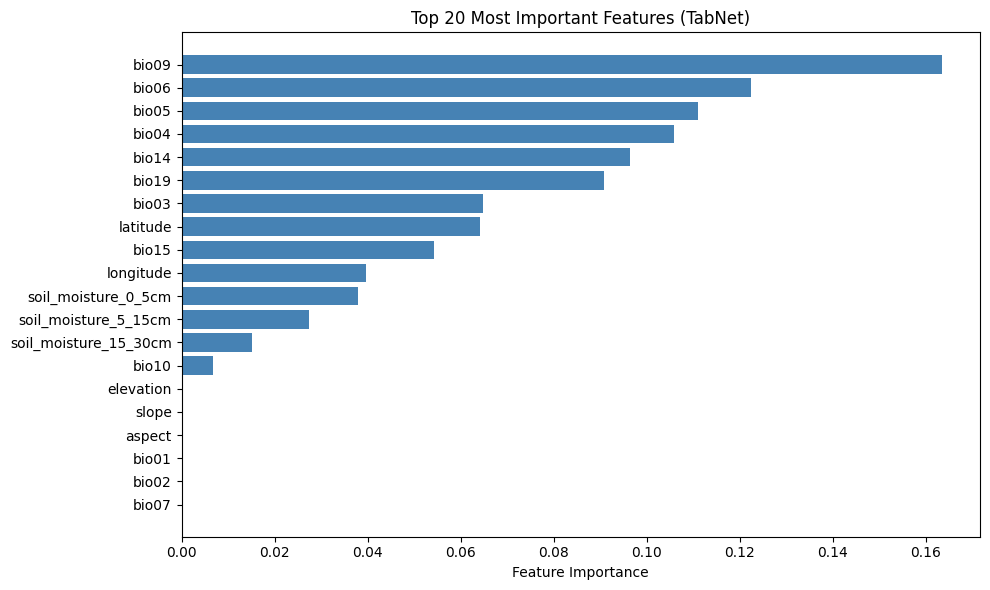

In [14]:
# Feature Importance Analysis
print("\n=== TabNet Feature Importance ===")

# Get feature importances from the trained model
feature_importances = tabnet_model.feature_importances_
print(f"Feature importances shape: {feature_importances.shape}")
print(f"Sum of importances: {feature_importances.sum():.4f}")

# Create a sorted list of (feature_name, importance) tuples
feature_importance_list = [(features[i], feature_importances[i]) for i in range(len(features))]
feature_importance_list.sort(key=lambda x: x[1], reverse=True)

# Print top 10 features
print("\nTop 10 Most Important Features:")
for i, (feat_name, importance) in enumerate(feature_importance_list[:10], 1):
    print(f"{i}. {feat_name}: {importance:.6f}")

# Plot top 20 features
top_n = min(20, len(feature_importance_list))
top_features = feature_importance_list[:top_n]
top_names, top_imps = zip(*top_features)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_names)), top_imps, color='steelblue')
plt.yticks(range(len(top_names)), top_names)
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Most Important Features (TabNet)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



=== TabNet Decision Masks Analysis ===
Extracting decision masks for 1000 test samples...
Number of decision steps detected: 1
  Step 1: shape (1000, 27), dtype float32, mean activation: 0.0358, max activation: 1.0822

Average Feature Activation by Step:
  Step 1: mean activation per feature: 0.0358


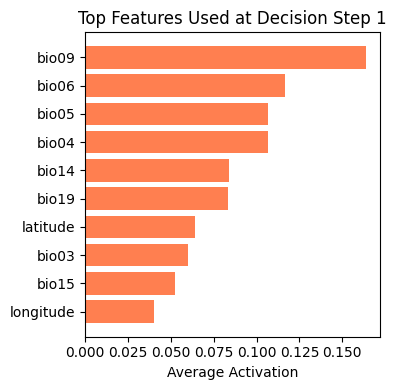


=== Decision Step Summary ===
Step 1: Features with non-zero activation (any sample): 14/27

Overall feature usage across all steps:
  Features used at any step: 14/27
  Avg times feature is used (count of steps where feature used on average): 14.00


In [17]:
# Decision Masks: Feature Usage Across Decision Steps
print("\n=== TabNet Decision Masks Analysis ===")

# Get the decision masks for test samples (shows which features are used at each step)
# Sample a subset to avoid memory issues
sample_size = min(1000, len(X_test_np))
X_test_sample = X_test_np[:sample_size]

print(f"Extracting decision masks for {sample_size} test samples...")
raw_masks = tabnet_model.explain(X_test_sample)

# Normalize different possible return formats from pytorch-tabnet
masks = None
if isinstance(raw_masks, dict):
    print("TabNet explain() returned a dict with keys:", list(raw_masks.keys()))
    # Common keys tried in order
    for key in ('masks', 'feature_masks', 'masks_list', 'explain'):
        if key in raw_masks:
            masks = raw_masks[key]
            break
    # Fall back to first list/ndarray-like value
    if masks is None:
        for v in raw_masks.values():
            if isinstance(v, (list, tuple, np.ndarray)):
                masks = v
                break
elif isinstance(raw_masks, tuple):
    # tuple often contains (explain_matrix, masks) or similar
    for elem in raw_masks:
        if isinstance(elem, (list, tuple, np.ndarray)):
            masks = elem
            break
else:
    masks = raw_masks

# Convert masks into a list of 2D numpy arrays, one per decision step
if isinstance(masks, np.ndarray):
    if masks.ndim == 3:
        # Try to infer axis ordering by locating the axis equal to number of features
        s0, s1, s2 = masks.shape
        feature_axis = None
        for idx, s in enumerate((s0, s1, s2)):
            if s == len(features):
                feature_axis = idx
                break
        if feature_axis is None:
            # if we can't find the features axis, assume (n_steps, n_samples, n_features)
            n_steps, n_samples, n_features = masks.shape
            masks = [masks[step].astype(np.float32) for step in range(n_steps)]
        else:
            # reorder so we get (n_steps, n_samples, n_features)
            if feature_axis == 2:
                # shapes: (n_steps, n_samples, n_features) or (n_samples, n_steps, n_features)
                if s0 == sample_size:
                    # (n_samples, n_steps, n_features) -> transpose to (n_steps, n_samples, n_features)
                    masks = np.transpose(masks, (1,0,2))
                else:
                    # assume already (n_steps, n_samples, n_features)
                    pass
            elif feature_axis == 1:
                # shape like (n_steps, n_features, n_samples) or (n_features, n_steps, n_samples)
                masks = np.transpose(masks, (0,2,1))
            elif feature_axis == 0:
                # shape like (n_features, n_samples, n_steps) -> bring n_steps to front
                masks = np.transpose(masks, (2,1,0))
            # now ensure masks is list of (n_samples, n_features)
            if isinstance(masks, np.ndarray):
                masks = [masks[step].astype(np.float32) for step in range(masks.shape[0])]
    elif masks.ndim == 2:
        # single-step mask with shape (n_samples, n_features)
        masks = [masks.astype(np.float32)]
    else:
        raise ValueError(f"Unexpected ndarray shape for masks: {masks.shape}")
elif isinstance(masks, (list, tuple)):
    masks = [np.asarray(m).astype(np.float32) for m in masks]
else:
    raise ValueError(f"Unable to interpret TabNet explain() output of type {type(raw_masks)}")

# Final sanity checks: ensure each mask is 2D and has n_features columns
for i, mask in enumerate(masks):
    if mask.ndim != 2:
        raise ValueError(f"Mask at step {i} is not 2D (shape={mask.shape})")
    if mask.shape[1] != len(features):
        raise ValueError(f"Mask at step {i} has {mask.shape[1]} features but expected {len(features)}")

print(f"Number of decision steps detected: {len(masks)}")
for step_idx, mask in enumerate(masks):
    print(f"  Step {step_idx+1}: shape {mask.shape}, dtype {mask.dtype}, "
          f"mean activation: {mask.mean():.4f}, max activation: {mask.max():.4f}")

# Aggregate masks: compute average activation across all samples for each step
print("\nAverage Feature Activation by Step:")
step_activations = []
for step_idx, mask in enumerate(masks):
    avg_activation = mask.mean(axis=0)  # average across samples
    step_activations.append(avg_activation)
    print(f"  Step {step_idx+1}: mean activation per feature: {avg_activation.mean():.4f}")

# Plot average feature usage across steps
fig, axes = plt.subplots(1, len(masks), figsize=(4*len(masks), 4))
if len(masks) == 1:
    axes = [axes]

for step_idx, activation in enumerate(step_activations):
    ax = axes[step_idx]
    # Show top features used at this step
    top_indices = np.argsort(activation)[-10:][::-1]
    top_feature_names = [features[i] for i in top_indices]
    top_activations = activation[top_indices]
    
    ax.barh(range(len(top_feature_names)), top_activations, color='coral')
    ax.set_yticks(range(len(top_feature_names)))
    ax.set_yticklabels(top_feature_names)
    ax.set_xlabel('Average Activation')
    ax.set_title(f'Top Features Used at Decision Step {step_idx+1}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Decision Step Summary ===")
# count features used at any sample in each step (not total non-zero entries)
total_features_by_step = [np.sum((mask > 0).any(axis=0)) for mask in masks]
for step_idx, total in enumerate(total_features_by_step):
    print(f"Step {step_idx+1}: Features with non-zero activation (any sample): {total}/{len(features)}")

print(f"\nOverall feature usage across all steps:")
all_masks_combined = np.concatenate(masks, axis=0)  # stack samples across steps
features_ever_used_bool = (all_masks_combined > 0).any(axis=0)
features_ever_used_count = int(features_ever_used_bool.sum())
print(f"  Features used at any step: {features_ever_used_count}/{len(features)}")
print(f"  Avg times feature is used (count of steps where feature used on average): {np.mean([np.sum((mask>0).any(axis=0)) for mask in masks]):.2f}")
